# Preços de combustíveis no Brasil

Começando a análise. O objetivo é identificar tendências, diferenças regionais, extremos, anomalias e oportunidades no período disponível. A leitura é voltada a analistas especializados em mercado de combustíveis.

## Como os dados estão estruturados?

Vamos confirmar o tamanho da base, os rótulos e as primeiras linhas antes de transformar qualquer campo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
from datetime import date, timedelta

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.3f}'.format

In [2]:
COR_PRIMARIA, COR_SECUNDARIA = '#0072B2', '#94A3B8'
COR_DESTAQUE, COR_EIXO, COR_TEXTO = '#E69F00', '#B0B7C3', '#334155'
PALETA = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#56B4E9', '#D55E00']
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 110, 'font.size': 11,
    'text.color': COR_TEXTO, 'axes.titlesize': 15, 'axes.titleweight': 'bold',
    'axes.labelcolor': COR_EIXO, 'axes.edgecolor': COR_EIXO, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': False, 'xtick.color': COR_EIXO,
    'ytick.color': COR_EIXO, 'axes.prop_cycle': plt.cycler(color=PALETA)})

In [3]:
arquivo = '../../data/postos_combustivel.tsv'
df = pd.read_csv(arquivo, sep='\t', encoding='utf-8')
print('Dimensões:', df.shape)
print('Período:', df['DATA INICIAL'].min(), 'a', df['DATA FINAL'].max())
df.head(3)

Dimensões: (120823, 18)
Período: 2004-05-09 a 2021-05-01


,DATA INICIAL,DATA FINAL,REGIÃO,ESTADO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,MARGEM MÉDIA REVENDA,COEF DE VARIAÇÃO REVENDA,PREÇO MÉDIO DISTRIBUIÇÃO,DESVIO PADRÃO DISTRIBUIÇÃO,PREÇO MÍNIMO DISTRIBUIÇÃO,PREÇO MÁXIMO DISTRIBUIÇÃO,COEF DE VARIAÇÃO DISTRIBUIÇÃO
0,2004-05-09,2004-05-15,CENTRO OESTE,DISTRITO FEDERAL,ETANOL HIDRATADO,127,R$/l,1.288,0.016,1.190,1.350,0.463,0.012,0.825,0.11,0.4201,0.9666,0.133
1,2004-05-09,2004-05-15,CENTRO OESTE,GOIAS,ETANOL HIDRATADO,387,R$/l,1.162,0.114,0.890,1.449,0.399,0.098,0.763,0.088,0.5013,1.05,0.115
2,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO,ETANOL HIDRATADO,192,R$/l,1.389,0.097,1.180,1.760,0.419,0.070,0.97,0.095,0.5614,1.161,0.098


**Verificação da leitura:** o separador tabular, o encoding UTF-8 e os rótulos com acentos foram reconhecidos. As datas ainda estão como texto e algumas medidas numéricas vieram como texto; isso será corrigido explicitamente.

## Há faltas, formatos inconsistentes ou produtos duplicados por grafia?

Primeiro mediremos a cobertura e os valores não numéricos. Depois aplicaremos a normalização solicitada, sem alterar o arquivo original.

In [4]:
numericas = ['NÚMERO DE POSTOS PESQUISADOS', 'PREÇO MÉDIO REVENDA', 'DESVIO PADRÃO REVENDA',
    'PREÇO MÍNIMO REVENDA', 'PREÇO MÁXIMO REVENDA', 'MARGEM MÉDIA REVENDA',
    'COEF DE VARIAÇÃO REVENDA', 'PREÇO MÉDIO DISTRIBUIÇÃO',
    'DESVIO PADRÃO DISTRIBUIÇÃO', 'PREÇO MÍNIMO DISTRIBUIÇÃO',
    'PREÇO MÁXIMO DISTRIBUIÇÃO', 'COEF DE VARIAÇÃO DISTRIBUIÇÃO']
print('Nulos por coluna:')
print(df.isna().sum().to_frame('nulos').query('nulos > 0'))
print('Produtos antes da normalização:')
df['PRODUTO'].value_counts().to_frame('registros')

Nulos por coluna:
Empty DataFrame
Columns: [nulos]
Index: []
Produtos antes da normalização:


,registros
PRODUTO,
GASOLINA COMUM,23570
GLP,23561
ETANOL HIDRATADO,23440
ÓLEO DIESEL,21194
GNV,14469
ÓLEO DIESEL S10,9113
OLEO DIESEL S10,2376
OLEO DIESEL,2351
GASOLINA ADITIVADA,749


In [5]:
def normaliza_texto(valor):
    texto = unicodedata.normalize('NFKD', str(valor)).encode('ascii', 'ignore').decode('ascii')
    return ' '.join(texto.upper().split())

df['PRODUTO'] = df['PRODUTO'].map(normaliza_texto)
for coluna in numericas[1:]:
    df[coluna] = pd.to_numeric(df[coluna], errors='coerce').fillna(0)
df['DATA INICIAL'] = pd.to_datetime(df['DATA INICIAL'])
df['DATA FINAL'] = pd.to_datetime(df['DATA FINAL'])
df[['PRODUTO', 'DATA INICIAL'] + numericas[1:4]].head(3)

,PRODUTO,DATA INICIAL,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA
0,ETANOL HIDRATADO,2004-05-09,1.288,0.016,1.190
1,ETANOL HIDRATADO,2004-05-09,1.162,0.114,0.890
2,ETANOL HIDRATADO,2004-05-09,1.389,0.097,1.180


**Tratamento aplicado:** produtos foram padronizados sem acentos e em caixa alta; textos numéricos inválidos ou ausentes foram convertidos para `0`, conforme solicitado. Essa decisão pode reduzir médias quando a ausência representar falta de medição, portanto será considerada uma limitação.

## Como os preços médios de revenda evoluíram?

A tendência nacional será observada por produto, usando a média simples dos registros estaduais. Ela é uma referência de mercado, não uma média ponderada pelo volume vendido.

In [6]:
df['MÊS'] = df['DATA INICIAL'].dt.to_period('M').dt.to_timestamp()
tendencia = df.groupby(['MÊS', 'PRODUTO'], as_index=False)['PREÇO MÉDIO REVENDA'].mean()
produtos_principais = df['PRODUTO'].value_counts().head(6).index
tendencia[tendencia['PRODUTO'].isin(produtos_principais)].tail(6)

,MÊS,PRODUTO,PREÇO MÉDIO REVENDA
1115,2021-04-01,ETANOL HIDRATADO,4.424
1117,2021-04-01,GASOLINA COMUM,5.493
1118,2021-04-01,GLP,88.640
1119,2021-04-01,GNV,3.372
1120,2021-04-01,OLEO DIESEL,4.325
1121,2021-04-01,OLEO DIESEL S10,4.377


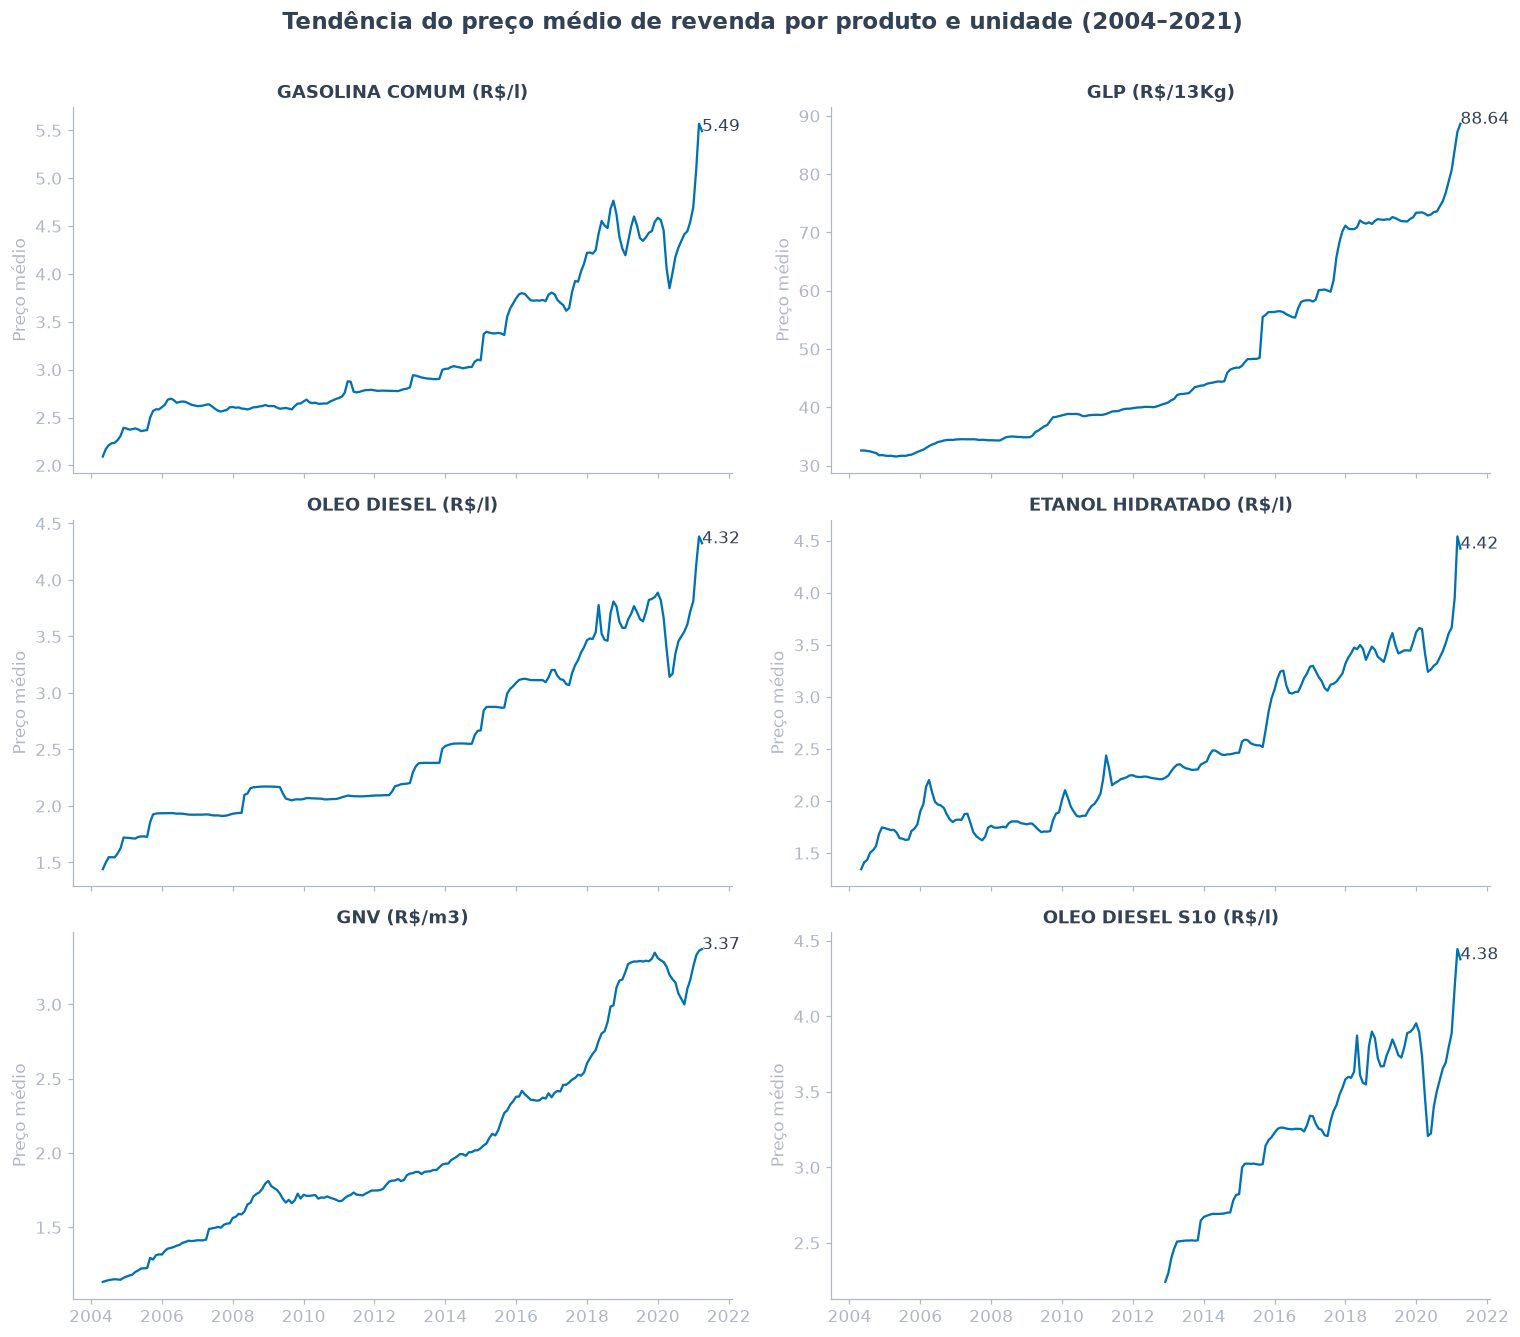

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
for ax, produto in zip(axes.flat, produtos_principais):
    serie = tendencia[tendencia['PRODUTO'] == produto]
    unidade = df.loc[df['PRODUTO'].eq(produto), 'UNIDADE DE MEDIDA'].mode().iat[0]
    ax.plot(serie['MÊS'], serie['PREÇO MÉDIO REVENDA'], color=COR_PRIMARIA)
    ultimo = serie.iloc[-1]
    ax.annotate(f"{ultimo['PREÇO MÉDIO REVENDA']:.2f}", (ultimo['MÊS'], ultimo['PREÇO MÉDIO REVENDA']))
    ax.set_title(f'{produto} ({unidade})', fontsize=12)
    ax.set_ylabel('Preço médio')
fig.suptitle('Tendência do preço médio de revenda por produto e unidade (2004–2021)', y=1.01, fontsize=15, fontweight='bold')
plt.tight_layout()

**Leitura crítica:** a série permite identificar ciclos e mudanças de nível, mas não separa inflação, composição estadual, qualidade do produto ou volume comercializado. O gráfico mostra associação temporal, não causa.

## Quais regiões apresentam os maiores e menores preços?

Vamos comparar regiões por produto no período completo e manter o número de registros para evitar rankings sem base suficiente.

In [8]:
regional = (df.groupby(['PRODUTO', 'REGIÃO'], as_index=False)
    .agg(preco_medio=('PREÇO MÉDIO REVENDA', 'mean'), registros=('PREÇO MÉDIO REVENDA', 'size'),
         postos_medios=('NÚMERO DE POSTOS PESQUISADOS', 'mean')))
regional.sort_values(['PRODUTO', 'preco_medio'], ascending=[True, False]).head(12)

,PRODUTO,REGIÃO,preco_medio,registros,postos_medios
2,ETANOL HIDRATADO,NORTE,2.655,5982,43.905
1,ETANOL HIDRATADO,NORDESTE,2.452,7856,147.942
4,ETANOL HIDRATADO,SUL,2.412,2618,427.837
3,ETANOL HIDRATADO,SUDESTE,2.293,3492,989.659
0,ETANOL HIDRATADO,CENTRO OESTE,2.246,3492,150.202
8,GASOLINA ADITIVADA,SUDESTE,5.116,112,227.857
5,GASOLINA ADITIVADA,CENTRO OESTE,5.095,112,39.973
6,GASOLINA ADITIVADA,NORDESTE,5.070,248,41.177
7,GASOLINA ADITIVADA,NORTE,5.020,193,18.756
9,GASOLINA ADITIVADA,SUL,4.908,84,118.738


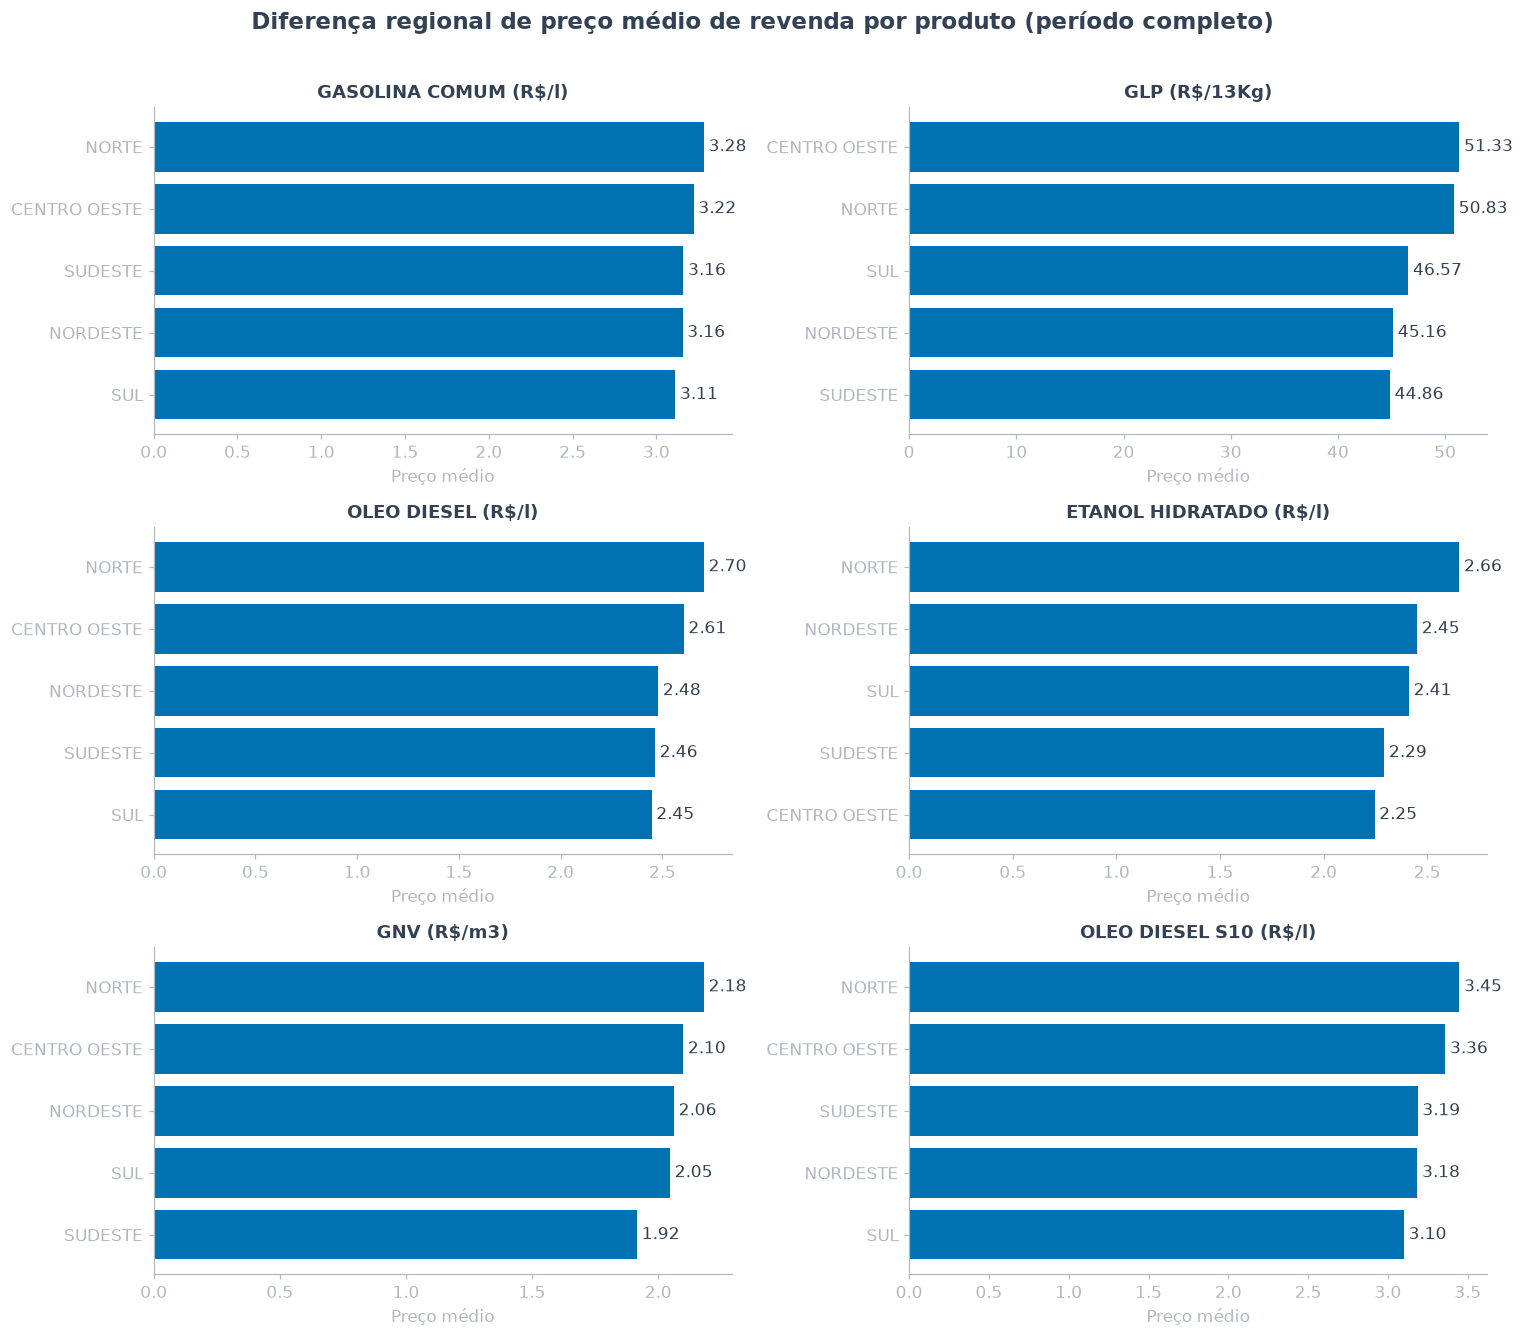

In [9]:
ranking = regional[regional['PRODUTO'].isin(produtos_principais)].pivot(index='PRODUTO', columns='REGIÃO', values='preco_medio')
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, produto in zip(axes.flat, produtos_principais):
    serie = ranking.loc[produto].sort_values()
    unidade = df.loc[df['PRODUTO'].eq(produto), 'UNIDADE DE MEDIDA'].mode().iat[0]
    barras = ax.barh(serie.index, serie.values, color=COR_PRIMARIA)
    ax.bar_label(barras, fmt='%.2f', padding=3)
    ax.set_title(f'{produto} ({unidade})', fontsize=12)
    ax.set_xlabel('Preço médio')
fig.suptitle('Diferença regional de preço médio de revenda por produto (período completo)', y=1.01, fontsize=15, fontweight='bold')
plt.tight_layout()

**Leitura crítica:** diferenças regionais são oportunidades de investigação comercial, mas a média simples pode refletir quantidade e composição dos estados pesquisados. Para decisão de preço, convém confirmar o recorte estadual e a comparabilidade da unidade.

## Onde estão os maiores e menores preços observados?

Os extremos ajudam a localizar mercados que merecem investigação, mas serão exibidos com data, produto, estado e número de postos para dar contexto ao valor.

In [10]:
colunas_extremo = ['DATA INICIAL', 'DATA FINAL', 'REGIÃO', 'ESTADO', 'PRODUTO', 'UNIDADE DE MEDIDA',
    'NÚMERO DE POSTOS PESQUISADOS', 'PREÇO MÉDIO REVENDA']
maiores = df.nlargest(10, 'PREÇO MÉDIO REVENDA')[colunas_extremo]
menores = df.nsmallest(10, 'PREÇO MÉDIO REVENDA')[colunas_extremo]
print('10 maiores preços médios:')
display(maiores)
print('10 menores preços médios:')
display(menores)

10 maiores preços médios:


,DATA INICIAL,DATA FINAL,REGIÃO,ESTADO,PRODUTO,UNIDADE DE MEDIDA,NÚMERO DE POSTOS PESQUISADOS,PREÇO MÉDIO REVENDA
119656,2021-03-14,2021-03-20,NORTE,ACRE,GLP,R$/13Kg,4,107.500
120200,2021-04-04,2021-04-10,CENTRO OESTE,MATO GROSSO,GLP,R$/13Kg,61,105.194
120557,2021-04-18,2021-04-24,CENTRO OESTE,MATO GROSSO,GLP,R$/13Kg,60,105.096
119844,2021-03-21,2021-03-27,CENTRO OESTE,MATO GROSSO,GLP,R$/13Kg,76,104.811
120736,2021-04-25,2021-05-01,CENTRO OESTE,MATO GROSSO,GLP,R$/13Kg,59,103.915
119836,2021-03-21,2021-03-27,NORTE,AMAPA,GLP,R$/13Kg,9,103.667
120379,2021-04-11,2021-04-17,CENTRO OESTE,MATO GROSSO,GLP,R$/13Kg,61,103.497
119478,2021-03-07,2021-03-13,NORTE,AMAPA,GLP,R$/13Kg,9,103.444
120371,2021-04-11,2021-04-17,NORTE,AMAPA,GLP,R$/13Kg,9,103.444
120022,2021-03-28,2021-04-03,CENTRO OESTE,MATO GROSSO,GLP,R$/13Kg,59,103.443


10 menores preços médios:


,DATA INICIAL,DATA FINAL,REGIÃO,ESTADO,PRODUTO,UNIDADE DE MEDIDA,NÚMERO DE POSTOS PESQUISADOS,PREÇO MÉDIO REVENDA
50,2004-05-16,2004-05-22,SUDESTE,SAO PAULO,ETANOL HIDRATADO,R$/l,4066,0.766
23,2004-05-09,2004-05-15,SUDESTE,SAO PAULO,ETANOL HIDRATADO,R$/l,4047,0.768
77,2004-05-23,2004-05-29,SUDESTE,SAO PAULO,ETANOL HIDRATADO,R$/l,4077,0.823
104,2004-05-30,2004-06-05,SUDESTE,SAO PAULO,ETANOL HIDRATADO,R$/l,4073,0.887
131,2004-06-06,2004-06-12,SUDESTE,SAO PAULO,ETANOL HIDRATADO,R$/l,4082,0.894
158,2004-06-13,2004-06-19,SUDESTE,SAO PAULO,ETANOL HIDRATADO,R$/l,4069,0.898
212,2004-06-27,2004-07-03,SUDESTE,SAO PAULO,ETANOL HIDRATADO,R$/l,4058,0.899
239,2004-07-04,2004-07-10,SUDESTE,SAO PAULO,ETANOL HIDRATADO,R$/l,4075,0.902
185,2004-06-20,2004-06-26,SUDESTE,SAO PAULO,ETANOL HIDRATADO,R$/l,4077,0.904
266,2004-07-11,2004-07-17,SUDESTE,SAO PAULO,ETANOL HIDRATADO,R$/l,4079,0.907


## Quais observações são anomalias de preço?

Usaremos um critério robusto por produto e estado: valores abaixo do primeiro quartil menos 1,5 intervalo interquartil ou acima do terceiro quartil mais 1,5 intervalo interquartil. Isso identifica pontos atípicos, não erros automaticamente.

In [11]:
grupo = df.groupby(['PRODUTO', 'ESTADO'])['PREÇO MÉDIO REVENDA']
q1 = grupo.transform(lambda s: s.quantile(.25))
q3 = grupo.transform(lambda s: s.quantile(.75))
iqr = q3 - q1
df['ANOMALIA_PRECO'] = (df['PREÇO MÉDIO REVENDA'] < q1 - 1.5 * iqr) | (df['PREÇO MÉDIO REVENDA'] > q3 + 1.5 * iqr)
anomalias = df[df['ANOMALIA_PRECO']]
print('Anomalias:', len(anomalias), f'({len(anomalias) / len(df):.2%} da base)')
anomalias.groupby(['PRODUTO', 'REGIÃO']).size().sort_values(ascending=False).head(10).to_frame('anomalias')

Anomalias: 825 (0.68% da base)


anomalias
PRODUTO        REGIÃO                 
GNV            NORDESTE            260
               SUDESTE             173
GLP            NORDESTE             56
GASOLINA COMUM NORDESTE             49
GNV            SUL                  48
GLP            NORTE                44
GASOLINA COMUM CENTRO OESTE         36
               SUDESTE              29
GNV            CENTRO OESTE         24
GASOLINA COMUM NORTE                21

**Leitura crítica:** o denominador é o total de registros e o critério é relativo a cada combinação produto–estado. Assim, regiões com mais observações tendem a acumular mais ocorrências absolutas; a taxa regional deve ser usada para priorizar investigação.

In [12]:
taxa_anomalia = (df.groupby(['PRODUTO', 'REGIÃO'])
    .agg(registros=('ANOMALIA_PRECO', 'size'), anomalias=('ANOMALIA_PRECO', 'sum'))
    .assign(taxa=lambda x: x['anomalias'] / x['registros'])
    .query('registros >= 30').sort_values('taxa', ascending=False))
taxa_anomalia.head(12)

registros  anomalias  taxa
PRODUTO        REGIÃO                                  
GNV            SUDESTE            3488        173 0.050
               NORDESTE           6180        260 0.042
               SUL                2607         48 0.018
               CENTRO OESTE       1671         24 0.014
               NORTE               523          7 0.013
GASOLINA COMUM CENTRO OESTE       3492         36 0.010
               SUDESTE            3492         29 0.008
GLP            SUL                2619         21 0.008
               NORTE              6110         44 0.007
               NORDESTE           7853         56 0.007
GASOLINA COMUM NORDESTE           7857         49 0.006
               SUL                2619         12 0.005

## As semanas com feriados apresentam preços atípicos?

O arquivo não possui uma coluna de feriado. Vamos marcar semanas que contêm feriados nacionais recorrentes e comparar a média da semana com a média das demais semanas, sem afirmar que o feriado causou a diferença.

In [13]:
def pascoa(ano):
    a = ano % 19; b = ano // 100; c = ano % 100; d = b // 4; e = b % 4; f = (b + 8) // 25; g = (b - f + 1) // 3
    h = (19*a + b - d - g + 15) % 30; i = c // 4; k = c % 4; l = (32 + 2*e + 2*i - h - k) % 7; m = (a + 11*h + 22*l) // 451
    mes = (h + l - 7*m + 114) // 31; dia = ((h + l - 7*m + 114) % 31) + 1
    return date(ano, mes, dia)

feriados = set()
for ano in range(df['DATA INICIAL'].dt.year.min(), df['DATA FINAL'].dt.year.max() + 1):
    pas = pascoa(ano)
    feriados.update(date(ano, m, d) for m, d in [(1,1),(4,21),(5,1),(9,7),(10,12),(11,2),(11,15),(12,25)])
    feriados.update(pas + timedelta(days=n) for n in [-48, -47, -2, 60])
df['TEM_FERIADO'] = df['DATA INICIAL'].map(lambda d: any(d.date() <= f <= (d + pd.Timedelta(days=6)).date() for f in feriados))
df.groupby('TEM_FERIADO')['PREÇO MÉDIO REVENDA'].agg(['count', 'mean', 'median']).rename(index={False: 'Sem feriado', True: 'Com feriado'})

,count,mean,median
TEM_FERIADO,,,
Sem feriado,95292,11.450,2.891
Com feriado,25531,11.561,2.936


**Leitura crítica:** essa comparação é exploratória. A marcação usa a semana do registro e feriados nacionais, sem controlar por produto, estado, sazonalidade ou choques de mercado; portanto, qualquer diferença deve ser tratada como sinal para investigação.

## Síntese para priorização

- **Achados:** use as séries temporais para localizar mudanças de nível; o ranking regional mostra onde há maior dispersão de preço; extremos e taxas de anomalia apontam mercados para validação.
- **Oportunidades:** priorizar estados/regiões com preço persistentemente alto, baixa margem relativa ou taxa elevada de anomalias, sempre conferindo o número de postos pesquisados.
- **Limitações:** a base é agregada, não traz volume vendido, custos, inflação, concorrência, localização ou indicador oficial de feriado; valores ausentes foram convertidos para zero por decisão do usuário.
- **Próximas decisões:** aprofundar por estado e produto, calcular evolução real corrigida por inflação e validar anomalias contra boletins ou fontes de preço locais antes de uma ação comercial.